# Actividad 3
* Reto 1
  *   Determina los unbrales de los colores rojo y amarillo en  base a la imagen propuesta en este material (HSV.png)

<img src="IMG/HSV.png" alt="HSV.png" width="200">

  *   De las siguientes **(contorno2.png y Ejemplo2.png)** imagenes obtiene todos los contronos que corresponde al color de cada figura.

<img src="IMG/contorno2.png" alt="contorno2.png" width="200"><img src="IMG/Ejemplo2.png" alt="Ejemplo2.png.png" width="200">

 * Para la imagen Contorno 2.png.
   *  Los color de los contornos de las figuras seran de las sigueinte forma: 
   *  figuras de color azul el contorno sera de color rojo. 
   *  figuras de color rojo el contorno sera de color amarillo. 
   *  figuras de color amarillo el contorno sera de color azul. 
* Reto 2
 *   De las siguinetes imagenes **(Figuras.png y Suavizado.png)** determina las imagen que corresponde a un mismo color y coloca un contorno de color y tamaño del borde a tu eleccion. 
 
 <img src="IMG/Figuras.png" alt="Figuras.png" width="200"><img src="IMG/Suavizado.png" alt="Suavizado.png" width="200">



Librerías

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

RETO 1 — Umbrales HSV (Rojo y Amarillo)

Cargar imagen HSV

(np.float64(-0.5), np.float64(719.5), np.float64(354.5), np.float64(-0.5))

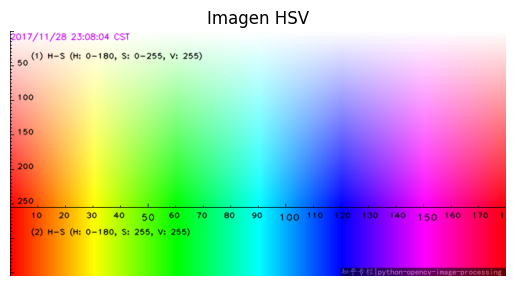

In [14]:
img_hsv = cv2.imread('IMG/HSV.png')
hsv = cv2.cvtColor(img_hsv, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_BGR2RGB))
plt.title("Imagen HSV")
plt.axis('off')

Rangos de color

In [15]:
# ROJO (tiene dos rangos en HSV)
rojo_bajo1 = np.array([0, 100, 100])
rojo_alto1 = np.array([10, 255, 255])

rojo_bajo2 = np.array([160, 100, 100])
rojo_alto2 = np.array([179, 255, 255])

# AMARILLO
amarillo_bajo = np.array([20, 100, 100])
amarillo_alto = np.array([35, 255, 255])

Máscaras de color

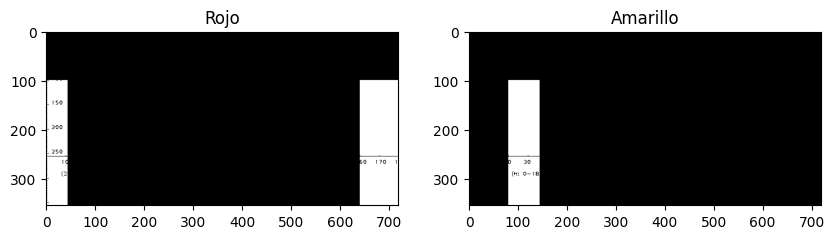

In [16]:
mask_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
mask_rojo = mask_rojo1 + mask_rojo2

mask_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_rojo, cmap='gray')
plt.title("Rojo")

plt.subplot(1,2,2)
plt.imshow(mask_amarillo, cmap='gray')
plt.title("Amarillo")

plt.show()

RETO 1 — Contornos por color (contorno2.png)

Cargar imagen

(np.float64(-0.5), np.float64(658.5), np.float64(492.5), np.float64(-0.5))

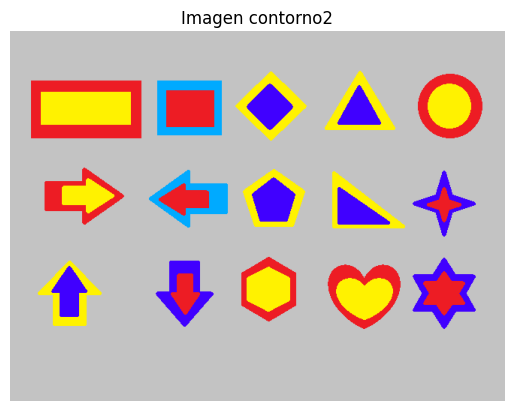

In [17]:
img = cv2.imread('IMG/contorno2.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen contorno2")
plt.axis('off')

Definir azul también

In [18]:
# AZUL
azul_bajo = np.array([100, 100, 100])
azul_alto = np.array([130, 255, 255])

mask_azul = cv2.inRange(hsv, azul_bajo, azul_alto)

Crear máscaras completas

In [19]:
# Ya teníamos rojo y amarillo
mask_rojo1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
mask_rojo2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
mask_rojo = mask_rojo1 + mask_rojo2

mask_amarillo = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)

Encontrar contornos

In [20]:
cont_rojo, _ = cv2.findContours(mask_rojo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont_amarillo, _ = cv2.findContours(mask_amarillo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont_azul, _ = cv2.findContours(mask_azul, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Dibujar contornos con reglas pedidas

(np.float64(-0.5), np.float64(658.5), np.float64(492.5), np.float64(-0.5))

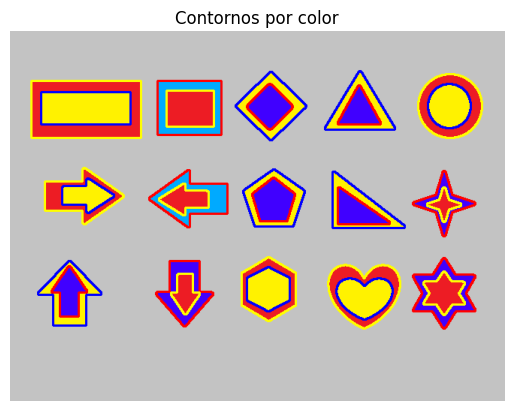

In [21]:
resultado = img.copy()

# Azul → contorno rojo
cv2.drawContours(resultado, cont_azul, -1, (0,0,255), 2)

# Rojo → contorno amarillo
cv2.drawContours(resultado, cont_rojo, -1, (0,255,255), 2)

# Amarillo → contorno azul
cv2.drawContours(resultado, cont_amarillo, -1, (255,0,0), 2)

plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Contornos por color")
plt.axis('off')

RETO 2 — Detectar mismo color (Figuras.png y Suavizado.png)

Cargar imágenes

In [22]:
img1 = cv2.imread('IMG/Figuras.png')
img2 = cv2.imread('IMG/Suavizado.png')

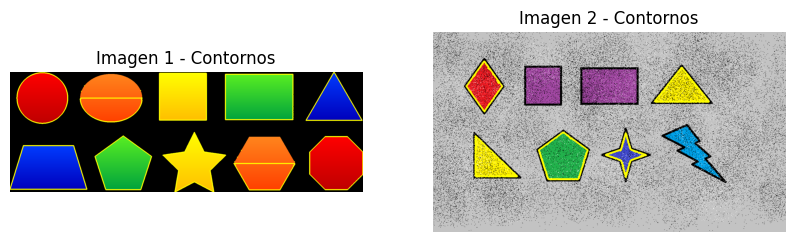

In [23]:
                

# Convertir a HSV
hsv1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
hsv2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

# Definir rangos de colores (puedes ajustarlos)
colores = {
    "rojo": [
        (np.array([0, 120, 70]), np.array([10, 255, 255])),
        (np.array([170, 120, 70]), np.array([180, 255, 255]))
    ],
    "amarillo": [
        (np.array([20, 100, 100]), np.array([30, 255, 255]))
    ],
    "azul": [
        (np.array([100, 150, 0]), np.array([140, 255, 255]))
    ],
    "verde": [
        (np.array([40, 70, 70]), np.array([80, 255, 255]))
    ]
}

# Color del contorno (el mismo para ambas imágenes)
color_borde = (0, 255, 255)  # amarillo (BGR)
grosor = 3

# Copias para dibujar
res1 = img1.copy()
res2 = img2.copy()

# Procesar cada color
for color, rangos in colores.items():
    
    mask1_total = None
    mask2_total = None

    # Crear máscaras (por si hay 2 rangos como rojo)
    for bajo, alto in rangos:
        mask1 = cv2.inRange(hsv1, bajo, alto)
        mask2 = cv2.inRange(hsv2, bajo, alto)

        if mask1_total is None:
            mask1_total = mask1
            mask2_total = mask2
        else:
            mask1_total = cv2.add(mask1_total, mask1)
            mask2_total = cv2.add(mask2_total, mask2)

    # Encontrar contornos
    contornos1, _ = cv2.findContours(mask1_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contornos2, _ = cv2.findContours(mask2_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Dibujar contornos en ambas imágenes
    cv2.drawContours(res1, contornos1, -1, color_borde, grosor)
    cv2.drawContours(res2, contornos2, -1, color_borde, grosor)

# Mostrar resultados
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(res1, cv2.COLOR_BGR2RGB))
plt.title("Imagen 1 - Contornos")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(res2, cv2.COLOR_BGR2RGB))
plt.title("Imagen 2 - Contornos")
plt.axis('off')

plt.show()

In [24]:
cap = cv2.VideoCapture(0)

# Rangos HSV para varios colores
rangos = {       
    'rojo': [
        (np.array([0, 120, 70]), np.array([10, 255, 255])),
        (np.array([170, 120, 70]), np.array([180, 255, 255]))
    ],
    'amarillo': [
        (np.array([20, 100, 100]), np.array([35, 255, 255]))
    ],
    'azul': [
        (np.array([90, 100, 70]), np.array([130, 255, 255]))
    ],
    'verde': [
        (np.array([40, 60, 60]), np.array([85, 255, 255]))
    ]
}

# Color de contorno por color detectado (BGR)
color_contorno = {
    'rojo': (0, 0, 255),
    'amarillo': (0, 255, 255),
    'azul': (255, 0, 0),
    'verde': (0, 255, 0)
}


if not cap.isOpened():
    print('No se pudo abrir la camara')
else:
    while True:
        ok, frame = cap.read()
        if not ok:
            print('No se pudo capturar frame')
            break

        hsv_cam = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        for nombre_color, lista_rangos in rangos.items():
            mascara_total = np.zeros(hsv_cam.shape[:2], dtype=np.uint8)

            for bajo, alto in lista_rangos:
                mascara = cv2.inRange(hsv_cam, bajo, alto)
                mascara_total = cv2.add(mascara_total, mascara)

            kernel = np.ones((5, 5), np.uint8)
            mascara_total = cv2.morphologyEx(mascara_total, cv2.MORPH_OPEN, kernel)
            mascara_total = cv2.morphologyEx(mascara_total, cv2.MORPH_CLOSE, kernel)

            contornos, _ = cv2.findContours(mascara_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for c in contornos:
                area = cv2.contourArea(c)
                if area < 400:
                    continue

                perimetro = cv2.arcLength(c, True)
                aprox = cv2.approxPolyDP(c, 0.04 * perimetro, True)

                figura = 'figura'
                if len(aprox) == 3:
                    figura = 'triangulo'
                elif len(aprox) == 4:
                    x, y, w, h = cv2.boundingRect(aprox)
                    relacion = w / float(h)
                    if 0.90 <= relacion <= 1.10:
                        figura = 'cuadrado'
                    else:
                        figura = 'rectangulo'
                elif len(aprox) > 4:
                    figura = 'circulo'

                cv2.drawContours(frame, [aprox], -1, color_contorno[nombre_color], 3)

                x, y, w, h = cv2.boundingRect(aprox)
                texto = nombre_color + ' - ' + figura
                cv2.putText(frame, texto, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_contorno[nombre_color], 2)

        cv2.imshow('Camara: deteccion de colores y figuras', frame)

        tecla = cv2.waitKey(1) & 0xFF
        if tecla == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()